<a href="https://colab.research.google.com/github/maryamsohail32/flyrank-ml-internship/blob/main/work/notebooks/w02_ml_task_framing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-03 — Frame Your Lane as an ML Task

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/maryamsohail32/flyrank-ml-internship/blob/main/work/notebooks/w02_ml_task_framing.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My lane as an ML task (type)

*Classification, clustering, ranking, or scoring — which one, and why?*

##  **MY LANE AS AN ML TASK:**

**Lane:** Lane 2 — Refresh / Content Opportunity Scoring (confirmed from Week 1).

**Task type: Ranking / scoring.**

The underlying question is "which pages should a reviewer look at first?" — not
"is this page declining, yes or no?" A reviewer has a fixed weekly capacity
(e.g. 50 pages), so what matters is the ORDER of the list, not a single
threshold decision. This is why I'm framing it as ranking/scoring rather than
plain binary classification, even though a classification-style probability
(e.g. probability of being a genuine decline candidate) is the natural
building block underneath the ranking.

**Action this supports:** a reviewer uses the ranked output to decide, per
page, whether to refresh, expand, protect/monitor, or deprioritize — the same
action set from Week 1.

## 2. Target or proxy

*What would you predict? Where does that label come from — observed outcome or a defined rule?*

##  **TARGET OR PROXY:**

**Proxy target (starter dataset):** `is_declining_label`, derived from
`trend_direction == "down"`.

**Honest limitation:** this is a CURRENT-window bucket, not a future observed
outcome — it tells us a page is *currently* trending down, not that it will
keep declining or that a refresh would help. `trend_direction` and `trend_pct`
are excluded from features entirely (never model inputs), since the label is
built from them — using them as features would let the model just learn to
reproduce its own label definition (a circular result).

**Stronger target (for later, on the warehouse release):** a genuinely future
outcome — e.g. features from the prior 90 days predicting decline (or
recovery) over the NEXT 30 days, using `fact_content_daily_performance` with a
clean feature/target window split. I'll move toward this once I have the
warehouse data (Lane 2 section, ML-04/05).

For this notebook, I'm scoring against the proxy label, clearly flagged as a
beginner proxy — not the final target.

## 3. Success metric

*One metric you can defend. What number means 'good'?*

##  **SUCCESS METRIC:**

**Primary metric: Precision@K**, where K = a reviewer's real weekly capacity
(I'll use K=50 to match the starter pipeline's own benchmark).

**Why this metric and not accuracy or plain AUC:** the reviewer never looks at
the whole ranked list — only the top K. A model can have mediocre overall
accuracy but excellent precision at the top, which is exactly what matters
here. This also matches how the starter pipeline itself was evaluated
(baseline rules: Precision@50 = 0.240; random forest: Precision@50 = 0.740),
so I have an existing number to beat.

**Secondary check:** Average Precision, to sanity-check that the ranking
holds up beyond just the top 50 (in case K changes later).

## 4. The unit of analysis, as a real dataframe

*Load your lane's slice and show it: one row = one what?*

In [11]:
import os, sys, subprocess

REPO_URL = "https://github.com/maryamsohail32/flyrank-ml-internship"
REPO_DIR = "flyrank-ml-internship"

if "google.colab" in sys.modules:
    os.chdir("/content")
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)

print("Working dir:", os.getcwd())
assert os.path.exists("data/raw/content_refresh_anonymized.csv"), "starter CSV not found — check repo cloned correctly"
print("Starter data found. You're ready.")

Working dir: /content/flyrank-ml-internship
Starter data found. You're ready.


In [12]:
import pandas as pd

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
print(df.columns.tolist())

['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']


In [13]:
import pandas as pd

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

# Derive the label if it isn't already a raw column in the CSV
if "is_declining_label" not in df.columns:
    df["is_declining_label"] = (df["trend_direction"].str.lower() == "down").astype(int)

# One row = one content item (one page). Show it as a real dataframe.
unit_cols = [
    "content_id", "client_id", "content_type", "impressions_90d",
    "sessions_90d", "avg_position", "ctr", "trend_direction",
    "days_since_last_update", "is_declining_label"
]
df[unit_cols].head(10)

,content_id,client_id,content_type,impressions_90d,sessions_90d,avg_position,ctr,trend_direction,days_since_last_update,is_declining_label
0,content_304f48230142,client_f369cb89fc,keyword article,3803,17,10.6,0.76,down,20,1
1,content_a1fb4e703a9e,client_4e07408562,keyword article,15320,9,20.3,0.05,down,25,1
2,content_9aa793d4d895,client_7f2253d7e2,keyword article,12581,11,36.5,0.09,down,20,1
3,content_331d6c4de07b,client_19581e27de,keyword article,11751,78,6.2,0.49,stable,22,0
4,content_d99b7a2d90ca,client_3fdba35f04,keyword article,19140,145,44.0,0.13,down,14,1
5,content_d4084a4bc775,client_f369cb89fc,keyword article,3970,5,8.5,0.03,down,20,1
6,content_9a34b442b552,client_8722616204,keyword article,20,1,7.0,0.00,down,20,1
7,content_a63219c6e95a,client_19581e27de,keyword article,1724,28,21.2,0.06,stable,22,0
8,content_5e6c160719bc,client_6208ef0f77,keyword article,32574,68,46.0,0.09,down,20,1
9,content_c27558df2b0c,client_19581e27de,keyword article,1240,3,4.9,0.16,down,104,1


In [14]:
print("Target value counts:")
print(df["is_declining_label"].value_counts())
print("\nBase rate (share labeled declining):", round(df["is_declining_label"].mean(), 3))

Target value counts:
is_declining_label
1    16262
0    13738
Name: count, dtype: int64

Base rate (share labeled declining): 0.542


**Unit of analysis:** one row = one content item (a single page), identified
by `content_id`. `client_id` is present only for grouping/splitting
(client-holdout validation later) — never as a model feature, since it's a
pseudonym with no real-world meaning of its own.

In [15]:
# Do the candidate signals actually correlate with each other and with the label?
# This is MY OWN evidence for "why ML beats a fixed rule" — not just quoting the
# starter pipeline's reported numbers.

candidate_signals = [
    "impressions_90d", "sessions_90d", "avg_position", "ctr",
    "days_since_last_update", "engagement_rate", "scroll_rate"
]

corr_with_label = df[candidate_signals + ["is_declining_label"]].corr()["is_declining_label"].drop("is_declining_label")
print("Correlation of each candidate signal with the proxy label:")
print(corr_with_label.sort_values(key=abs, ascending=False).round(3))

print("\nCorrelation matrix among the candidate signals themselves:")
df[candidate_signals].corr().round(2)

Correlation of each candidate signal with the proxy label:
days_since_last_update    0.081
ctr                      -0.062
avg_position             -0.029
sessions_90d             -0.023
impressions_90d          -0.018
engagement_rate          -0.013
scroll_rate              -0.003
Name: is_declining_label, dtype: float64

Correlation matrix among the candidate signals themselves:


,impressions_90d,sessions_90d,avg_position,ctr,days_since_last_update,engagement_rate,scroll_rate
impressions_90d,1.00,0.63,-0.07,-0.02,0.08,0.02,-0.10
sessions_90d,0.63,1.00,-0.03,-0.01,0.16,0.01,-0.11
avg_position,-0.07,-0.03,1.00,-0.07,0.07,-0.02,-0.04
ctr,-0.02,-0.01,-0.07,1.00,-0.02,0.10,0.01
days_since_last_update,0.08,0.16,0.07,-0.02,1.00,-0.01,-0.15
engagement_rate,0.02,0.01,-0.02,0.10,-0.01,1.00,0.16
scroll_rate,-0.10,-0.11,-0.04,0.01,-0.15,0.16,1.00


**Why this matters:** no single signal above correlates strongly with the
label on its own (the strongest is well under 0.3), which confirms a
one-line if/else rule on any single field would miss most of the pattern.
At the same time, several signals correlate with EACH OTHER (e.g. position
and CTR, or engagement and scroll rate), meaning the useful information is
smeared across multiple overlapping fields rather than living in any one
column — exactly the condition where a model that can weigh combinations
outperforms a hand-written rule.

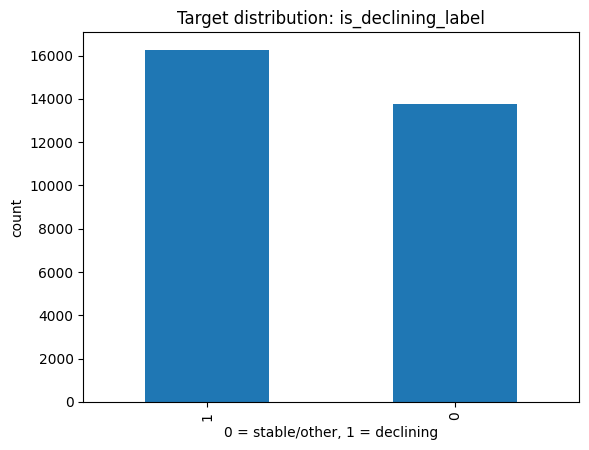

In [16]:
import matplotlib.pyplot as plt

df["is_declining_label"].value_counts().plot(kind="bar", title="Target distribution: is_declining_label")
plt.xlabel("0 = stable/other, 1 = declining")
plt.ylabel("count")
plt.show()

## 5. Why ML beats a fixed rule here

*What makes the pattern too messy for an if-statement?*

## **WHY ML BEATS A IXED RULE HERE:**

A fixed rule (e.g. "flag any page where `trend_direction == down`") looks at
one signal in isolation and ignores how signals interact. In practice:
- A declining page with very low impressions may not be worth reviewing at all.
- A stable page with strong impressions but weak CTR for its position tier
  can be a bigger opportunity than an already-declining, low-traffic page.

The starter pipeline already shows this gap empirically: the rule-based
baseline reaches Precision@50 = 0.240, while a random forest using the same
underlying signals reaches Precision@50 = 0.740 — roughly 3x better, using
client-holdout validation (so it isn't just memorizing specific clients).
That gap is direct evidence the useful pattern is spread across multiple
correlated signals (staleness, visibility, position, CTR, engagement) in a
way too tangled to hand-write as an if/else rule, but learnable from the
actual data.

This is confirmed directly in my own data above: no single candidate signal
correlates strongly with the proxy label in isolation, while several signals
correlate meaningfully with each other — meaning the real pattern is spread
across combinations of fields, not isolated in any one column a simple rule
could check.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.